Title: LEE_Detection.ipynb

Purpose: Identifiy Low Energy Events with varying lengths from the model output data

Author: Onno Nennecke on 21.03.2025 Modified: 18.07.2025

Input data: 

- adjusted final model output
    - This file lies here: '/climca/people/onennecke/model_output/not_bias_corrected/model_output_adj.nc'

Output data:

- LEE Tables
    - This file lies here: '/climca/people/onennecke/model_output/LEE_detection/'

In [1]:
# Importing libraries
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
import os
import glob

# Importing functions

### Read Model output data

In [2]:
path = '/climca/people/onennecke/model_output/not_bias_corrected/model_output_adj.nc'
ts_datasets = xr.open_dataset(path)
ts_datasets.load()

<xarray.Dataset> Size: 43MB
Dimensions:            (ESM_run: 102, time: 3650)
Coordinates:
    crs                int64 8B 4326
    gridtype           <U6 24B 'lonlat'
  * time               (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM                (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'SMARD'
    run                (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'hist'
  * ESM_run            (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'SMARD_hist'
    country            float64 8B 9.0
    period             (ESM_run) <U4 2kB 'week' 'week' 'week' ... 'week' 'wwd'
    doy                (time) int64 29kB 1 2 3 4 5 6 ... 360 361 362 363 364 365
Data variables: (12/16)
    temp               (ESM_run, time) float64 3MB 2.862 -0.3492 ... nan nan
    demand             (ESM_run, time) float64 3MB 1.485e+03 ... 1.204e+03
    sfcWind            (ESM_run, time) float64 3MB 8.056 6.177 6.451 ... nan nan
    rsds               (ESM_run, time) float32 1MB 13.75 24.11 38.15 ... nan nan
    tas                (ESM_run, time) float32 1MB 2.114 -0.7924 ... nan nan
    tasmax             (ESM_run, time) float32 1MB 4.033 0.7523 ... nan nan
    ...                 ...
    Netto              (ESM_run, time) float64 3MB -788.1 -915.8 ... nan nan
    Residual_load      (ESM_run, time) float64 3MB 788.1 915.8 ... 659.8 556.8
    solar_prod_adj     (ESM_run, time) float64 3MB -12.07 2.501 ... 22.93 49.09
    total_prod_adj     (ESM_run, time) float64 3MB 647.1 543.9 ... 618.5 647.4
    Netto_adjusted     (ESM_run, time) float64 3MB -837.5 -980.4 ... nan nan
    Residual_load_adj  (ESM_run, time) float64 3MB 837.5 980.4 ... 659.8 556.8

In [3]:
# path = '/climca/people/onennecke/model_output/bias_corrected_masked_ibicus/full_year/'
# files = sorted(glob.glob(path + '*.nc'))
# # files = files[:60] + files[61:]
# ts_datasets = xr.open_mfdataset(files, combine='nested', concat_dim = 'ESM_run')
# ts_datasets.coords['doy'] = (('time',), np.tile(np.arange(1, 366), 10))

# ts_datasets

#### Identification of low energy events

In [3]:
RL = ts_datasets['Residual_load_adj']
# RL = ts_datasets['Residual_load']

RL.values

array([[ 837.47183445,  980.37070577, 1078.0516186 , ..., 1349.55583696,
        1175.6584086 ,  821.39919539],
       [ 678.33783761,  694.67244101,  720.86882321, ...,  952.03285008,
         415.07498051,   97.03937429],
       [ 638.21959077, 1019.65071762, 1329.49457713, ..., 1388.84560078,
        1354.85477407,  786.40284627],
       ...,
       [ 753.11201985,  153.53757256, -123.46458643, ..., 1411.32620104,
        1577.94928817, 1415.70563765],
       [ 904.93211708, 1276.97146842, 1142.57921859, ...,  878.89076051,
         115.41281281,  221.48162857],
       [ 768.47225   ,  679.20575   ,  736.91175   , ...,  784.75025   ,
         659.8235    ,  556.83375   ]])

In [4]:
# Calculate the rolling means
ts_datasets['RL_mov_avg_7'] = RL_mov_avg_7 = RL.rolling(time=7, center=False).mean()
ts_datasets['RL_mov_avg_14'] = RL_mov_avg_14 = RL.rolling(time=14, center=False).mean()
# ts_datasets

In [5]:
ts_datasets.load()

<xarray.Dataset> Size: 49MB
Dimensions:            (ESM_run: 102, time: 3650)
Coordinates:
    crs                int64 8B 4326
    gridtype           <U6 24B 'lonlat'
  * time               (time) datetime64[ns] 29kB 2015-01-01 ... 2024-12-31
    ESM                (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'SMARD'
    run                (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'hist'
  * ESM_run            (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'SMARD_hist'
    country            float64 8B 9.0
    period             (ESM_run) <U4 2kB 'week' 'week' 'week' ... 'week' 'wwd'
    doy                (time) int64 29kB 1 2 3 4 5 6 ... 360 361 362 363 364 365
Data variables: (12/18)
    temp               (ESM_run, time) float64 3MB 2.862 -0.3492 ... nan nan
    demand             (ESM_run, time) float64 3MB 1.485e+03 ... 1.204e+03
    sfcWind            (ESM_run, time) float64 3MB 8.056 6.177 6.451 ... nan nan
    rsds               (ESM_run, time) float32 1MB 13.75 24.11 38.15 ... nan nan
    tas                (ESM_run, time) float32 1MB 2.114 -0.7924 ... nan nan
    tasmax             (ESM_run, time) float32 1MB 4.033 0.7523 ... nan nan
    ...                 ...
    solar_prod_adj     (ESM_run, time) float64 3MB -12.07 2.501 ... 22.93 49.09
    total_prod_adj     (ESM_run, time) float64 3MB 647.1 543.9 ... 618.5 647.4
    Netto_adjusted     (ESM_run, time) float64 3MB -837.5 -980.4 ... nan nan
    Residual_load_adj  (ESM_run, time) float64 3MB 837.5 980.4 ... 659.8 556.8
    RL_mov_avg_7       (ESM_run, time) float64 3MB nan nan nan ... 866.0 832.5
    RL_mov_avg_14      (ESM_run, time) float64 3MB nan nan nan ... 655.1 640.2

In [14]:
ts_datasets.ESM_run

<xarray.DataArray 'ESM_run' (ESM_run: 102)> Size: 9kB
array(['ACCESS-CM2_r1i1p1f1', 'ACCESS-CM2_r4i1p1f1', 'ACCESS-CM2_r5i1p1f1',
       'BCC-CSM2-MR_r1i1p1f1', 'CESM2_r10i1p1f1', 'CESM2_r11i1p1f1',
       'CESM2_r4i1p1f1', 'EC-Earth3_r101i1p1f1', 'EC-Earth3_r102i1p1f1',
       'EC-Earth3_r103i1p1f1', 'EC-Earth3_r104i1p1f1', 'EC-Earth3_r105i1p1f1',
       'EC-Earth3_r106i1p1f1', 'EC-Earth3_r107i1p1f1', 'EC-Earth3_r108i1p1f1',
       'EC-Earth3_r109i1p1f1', 'EC-Earth3_r110i1p1f1', 'EC-Earth3_r111i1p1f1',
       'EC-Earth3_r112i1p1f1', 'EC-Earth3_r113i1p1f1', 'EC-Earth3_r114i1p1f1',
       'EC-Earth3_r115i1p1f1', 'EC-Earth3_r116i1p1f1', 'EC-Earth3_r117i1p1f1',
       'EC-Earth3_r118i1p1f1', 'EC-Earth3_r119i1p1f1', 'EC-Earth3_r120i1p1f1',
       'EC-Earth3_r121i1p1f1', 'EC-Earth3_r122i1p1f1', 'EC-Earth3_r123i1p1f1',
       'EC-Earth3_r124i1p1f1', 'EC-Earth3_r125i1p1f1', 'EC-Earth3_r126i1p1f1',
       'EC-Earth3_r127i1p1f1', 'EC-Earth3_r128i1p1f1', 'EC-Earth3_r129i1p1f1',
       'EC-Earth3_r130i1p1f1', 'EC-Earth3_r131i1p1f1', 'EC-Earth3_r132i1p1f1',
       'EC-Earth3_r133i1p1f1', 'EC-Earth3_r134i1p1f1', 'EC-Earth3_r135i1p1f1',
       'EC-Earth3_r136i1p1f1', 'EC-Earth3_r137i1p1f1', 'EC-Earth3_r138i1p1f1',
       'EC-Earth3_r139i1p1f1', 'EC-Earth3_r140i1p1f1', 'EC-Earth3_r141i1p1f1',
       'EC-Earth3_r142i1p1f1', 'EC-Earth3_r143i1p1f1', 'EC-Earth3_r144i1p1f1',
       'EC-Earth3_r145i1p1f1', 'EC-Earth3_r146i1p1f1', 'EC-Earth3_r147i1p1f1',
       'EC-Earth3_r148i1p1f1', 'EC-Earth3_r149i1p1f1', 'EC-Earth3_r150i1p1f1',
       'EC-Earth3_r1i1p1f1', 'EC-Earth3_r4i1p1f1', 'EC-Earth3_r5i1p1f1',
       'ERA5_hist_week', 'ERA5_hist_wwd', 'GFDL-ESM4_r1i1p1f1',
       'KACE-1-0-G_r1i1p1f1', 'KACE-1-0-G_r2i1p1f1', 'KACE-1-0-G_r3i1p1f1',
       'MPI-ESM1-2-HR_r10i1p1f1', 'MPI-ESM1-2-HR_r1i1p1f1',
       'MPI-ESM1-2-HR_r2i1p1f1', 'MPI-ESM1-2-HR_r3i1p1f1',
       'MPI-ESM1-2-HR_r4i1p1f1', 'MPI-ESM1-2-HR_r5i1p1f1',
       'MPI-ESM1-2-HR_r6i1p1f1', 'MPI-ESM1-2-HR_r7i1p1f1',
       'MPI-ESM1-2-HR_r8i1p1f1', 'MPI-ESM1-2-HR_r9i1p1f1',
       'MRI-ESM2-0_r1i1p1f1', 'MRI-ESM2-0_r2i1p1f1', 'MRI-ESM2-0_r3i1p1f1',
       'MRI-ESM2-0_r4i1p1f1', 'MRI-ESM2-0_r5i1p1f1', 'TaiESM1_r1i1p1f1',
       'UKESM1-0-LL_r10i1p1f2', 'UKESM1-0-LL_r11i1p1f2',
       'UKESM1-0-LL_r12i1p1f2', 'UKESM1-0-LL_r13i1p1f2',
       'UKESM1-0-LL_r14i1p1f2', 'UKESM1-0-LL_r15i1p1f2',
       'UKESM1-0-LL_r16i1p1f2', 'UKESM1-0-LL_r17i1p1f2',
       'UKESM1-0-LL_r18i1p1f2', 'UKESM1-0-LL_r19i1p1f2',
       'UKESM1-0-LL_r1i1p1f2', 'UKESM1-0-LL_r2i1p1f2', 'UKESM1-0-LL_r3i1p1f2',
       'UKESM1-0-LL_r4i1p1f2', 'UKESM1-0-LL_r5i1p1f2', 'UKESM1-0-LL_r6i1p1f2',
       'UKESM1-0-LL_r7i1p1f2', 'UKESM1-0-LL_r8i1p1f2', 'UKESM1-0-LL_r9i1p1f2',
       'SMARD_hist'], dtype='<U23')
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
    ESM       (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'SMARD'
    run       (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2' 'hist'
  * ESM_run   (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'SMARD_hist'
    country   float64 8B 9.0
    period    (ESM_run) <U4 2kB 'week' 'week' 'week' ... 'week' 'week' 'wwd'

##### Threshold Calculation

In [28]:
thresh_perc = 0.95

In [34]:
# Select all ESM_runs with period 'week'
ts_datasets_week = ts_datasets.sel(ESM_run=ts_datasets.ESM_run[ts_datasets.period == 'week'])
RL_week = ts_datasets_week['Residual_load_adj']
threshold_week = np.quantile(RL_week.values.flatten(), thresh_perc)
threshold_week

np.float64(1398.1051299231501)

In [30]:
# Select the SMARD data
ts_datasets_SMARD = ts_datasets.sel(ESM_run='SMARD_hist')
RL_SMARD = ts_datasets_SMARD['Residual_load_adj']
threshold_SMARD = np.quantile(RL_SMARD.values.flatten(), thresh_perc)
threshold_SMARD

np.float64(1332.1978625)

In [31]:
# Select the ERA5_week data
ts_datasets_ERA5_week = ts_datasets.sel(ESM_run='ERA5_hist_week')
RL_ERA5_week = ts_datasets_ERA5_week['Residual_load_adj']
threshold_ERA5_week = np.quantile(RL_ERA5_week.values.flatten(), thresh_perc)
threshold_ERA5_week

np.float64(1398.5125297793247)

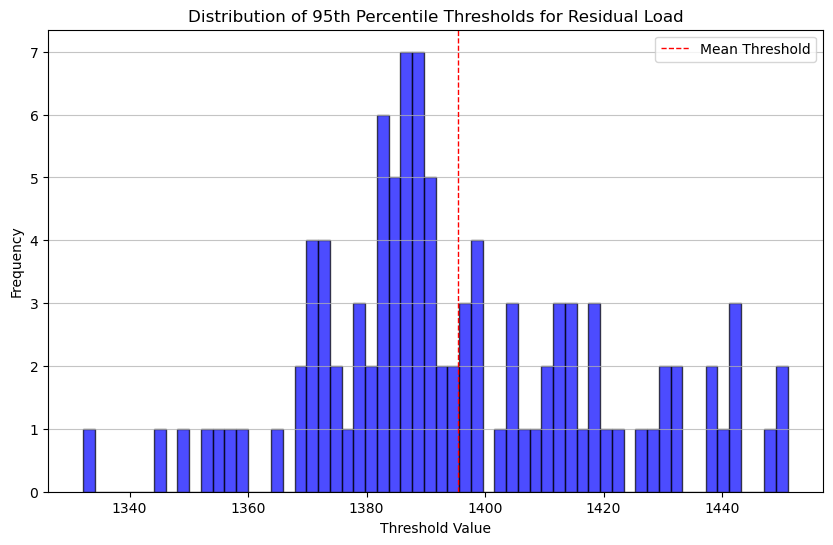

In [32]:
# Test
threshs = []
for esm_run in ts_datasets.ESM_run.values:
    ts_datasets_tst = ts_datasets.sel(ESM_run=esm_run)
    RL_tst = ts_datasets_tst['Residual_load_adj']
    threshold_tst = np.quantile(RL_tst.values.flatten(), thresh_perc)
    threshs.append(threshold_tst)

# Plot the thresholds as a distribution
plt.figure(figsize=(10, 6))
plt.hist(threshs, bins=60, color='blue', alpha=0.7, edgecolor='black')
plt.title('Distribution of 95th Percentile Thresholds for Residual Load')
plt.xlabel('Threshold Value')
plt.ylabel('Frequency')
plt.grid(axis='y', alpha=0.75)
plt.axvline(np.mean(threshs), color='red', linestyle='dashed', linewidth=1, label='Mean Threshold')
plt.legend()
plt.show()

In [ ]:
# Time series of "True" when threshold is exceeded, "False" otherwise

exceed_bool_1 = xr.where(RL > threshold_week, True, False)
exceed_bool_7 = xr.where(RL_mov_avg_7 > threshold_week, True, False)
exceed_bool_14 = xr.where(RL_mov_avg_14 > threshold_week, True, False)

In [36]:
# Look for events without any rolling mean


# Count number of true values overall
count_exceed_1 = exceed_bool_1.sum(dim='time').sum(dim='ESM_run')
count_exceed_1.values
# exceed_bool_1.time
# np.zeros_like(exceed_bool_1, dtype=int)

array(18606)

### Days above threshold (dat) 

- Take each day as its own event (not really events but just days above threshold)

In [37]:
# 1) Extract the flat indices where mask is True
run_idx, time_idx = np.nonzero(exceed_bool_1.values)
n_dat = run_idx.size

# 2) Create a flat counter 1…n_dat
labels = np.arange(1, n_dat + 1, dtype=int)

# 3) Scatter them back into an integer array of same shape
dat = np.zeros_like(exceed_bool_1.values, dtype=int)
dat[run_idx, time_idx] = labels

# wrap back into an xarray
dat = xr.DataArray(
    dat,
    coords=exceed_bool_1.coords,
    dims=exceed_bool_1.dims,
    name="dat"
)

n_dat = n_dat
dat

<xarray.DataArray 'dat' (ESM_run: 102, time: 3650)> Size: 3MB
array([[    0,     0,     0, ...,     0,     0,     0],
       [    0,     0,     0, ...,     0,     0,     0],
       [    0,     0,     0, ...,     0,     0,     0],
       ...,
       [    0,     0,     0, ..., 18261, 18262, 18263],
       [    0,     0,     0, ...,     0,     0,     0],
       [    0,     0,     0, ...,     0,     0,     0]])
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'SMARD'
    run       (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2' 'hist'
  * ESM_run   (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'SMARD_hist'
    country   float64 8B 9.0
    period    (ESM_run) <U4 2kB 'week' 'week' 'week' ... 'week' 'week' 'wwd'
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

In [38]:
# 1) Extract the flat indices where mask is True
run_idx, time_idx = np.nonzero(exceed_bool_7.values)
n_dat_7 = run_idx.size

# 2) Create a flat counter 1…n_dat_7
labels = np.arange(1, n_dat_7 + 1, dtype=int)

# 3) Scatter them back into an integer array of same shape
dat_7 = np.zeros_like(exceed_bool_7.values, dtype=int)
dat_7[run_idx, time_idx] = labels

# wrap back into an xarray
dat_7 = xr.DataArray(
    dat_7,
    coords=exceed_bool_7.coords,
    dims=exceed_bool_7.dims,
    name="dat_7"
)

n_dat_7 = n_dat_7
dat_7

<xarray.DataArray 'dat_7' (ESM_run: 102, time: 3650)> Size: 3MB
array([[   0,    0,    0, ...,    0,    0,    0],
       [   0,    0,    0, ...,    0,    0,    0],
       [   0,    0,    0, ...,    0,    0,    0],
       ...,
       [   0,    0,    0, ...,    0, 4190, 4191],
       [   0,    0,    0, ...,    0,    0,    0],
       [   0,    0,    0, ...,    0,    0,    0]])
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'SMARD'
    run       (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2' 'hist'
  * ESM_run   (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'SMARD_hist'
    country   float64 8B 9.0
    period    (ESM_run) <U4 2kB 'week' 'week' 'week' ... 'week' 'week' 'wwd'
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

In [39]:
# 1) Extract the flat indices where mask is True
run_idx, time_idx = np.nonzero(exceed_bool_14.values)
n_dat_14 = run_idx.size

# 2) Create a flat counter 1…n_dat_14
labels = np.arange(1, n_dat_14 + 1, dtype=int)

# 3) Scatter them back into an integer array of same shape
dat_14 = np.zeros_like(exceed_bool_14.values, dtype=int)
dat_14[run_idx, time_idx] = labels

# wrap back into an xarray
dat_14 = xr.DataArray(
    dat_14,
    coords=exceed_bool_14.coords,
    dims=exceed_bool_14.dims,
    name="dat_14"
)

n_dat_14 = n_dat_14
dat_14

<xarray.DataArray 'dat_14' (ESM_run: 102, time: 3650)> Size: 3MB
array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])
Coordinates:
    crs       int64 8B 4326
    gridtype  <U6 24B 'lonlat'
  * time      (time) datetime64[ns] 29kB 2015-01-01 2015-01-02 ... 2024-12-31
    ESM       (ESM_run) <U13 5kB 'ACCESS-CM2' 'ACCESS-CM2' ... 'SMARD'
    run       (ESM_run) <U10 4kB 'r1i1p1f1' 'r4i1p1f1' ... 'r9i1p1f2' 'hist'
  * ESM_run   (ESM_run) <U23 9kB 'ACCESS-CM2_r1i1p1f1' ... 'SMARD_hist'
    country   float64 8B 9.0
    period    (ESM_run) <U4 2kB 'week' 'week' 'week' ... 'week' 'week' 'wwd'
    doy       (time) int64 29kB 1 2 3 4 5 6 7 8 ... 359 360 361 362 363 364 365

### Events with rolling mean of 1 above threshold (events_vl) = events with varying length 

In [40]:
# Look for events without any rolling mean

events_vl = np.zeros_like(exceed_bool_1, dtype=int)

# Starting value for the labels
current_label = 1
counter = 0
for run in exceed_bool_1.ESM_run.values:
    run_data = exceed_bool_1.sel(ESM_run=run)
    # Only label this section
    labeled_segment, num_features = ndimage.label(run_data.values)

    if num_features > 0:
        labeled_segment[labeled_segment > 0] += current_label - 1
        current_label += num_features

    # Save the label to the result array
    events_vl[counter] = labeled_segment
    counter += 1

n_events_vl = current_label - 1
n_events_vl



9424

In [41]:
def LEE_detection(events, n_events, t=RL['time'].values, dur = 7, minDuration=1):
    LEE_records = []

    for i in range(len(RL.ESM_run)):
        for ev in range(1, n_events + 1):
            event_duration = (events[i] == ev).sum()
            if event_duration < minDuration:
                continue
            print(f"Processing event {ev} for run {i+1}/{len(RL.ESM_run)}")

            end_idx = np.where(events[i] == ev)[0][0]
            start_idx = end_idx - dur + 1

            date_start = t[start_idx]
            date_end = t[end_idx]

            LEE_start = np.where(t == date_start)[0][0]
            LEE_end = np.where(t == date_end)[0][0]

            RL_run = RL.sel(ESM_run=RL.ESM_run[i]).values
            RL_LEE = RL_run[LEE_start:LEE_end + 1]
            LEE_peak = np.argmax(RL_LEE)

            record = {
                'date_start': date_start,
                'date_end': date_end,
                'date_peak': date_start + LEE_peak,
                # 'date_start_old': RL['old_time'][i][LEE_start].values,
                # 'date_end_old': RL['old_time'][i][LEE_end].values,
                # 'date_peak_old': RL['old_time'][i][LEE_start + LEE_peak].values,
                'index_start': LEE_start,
                'index_end': LEE_end,
                'index_peak': LEE_start + LEE_peak,
                'duration': len(RL_LEE),
                'RL_max': RL_LEE[LEE_peak],
                'RL_mean': RL_LEE.mean(),
                'RL_var': np.sqrt(RL_LEE.var()),
                'RL_cumulative': RL_LEE.sum(),
                'event': ev,
                'ESM': str(RL.ESM[i].values),
                'ESM_run': str(RL.ESM_run[i].values),
                'year': RL.time.dt.year[start_idx].values,
                'doy' : RL.doy[start_idx].values#,
                # 'winter': RL.winter_year[start_idx].values,
                # 'day_of_winter': RL.day_of_winter[start_idx].values
            }

            # # Optional additional metrics if available
            # # (you could generalize this to loop over var names too)
            # for var in ['prod', 'demand', 'pot']:
            #     try:
            #         var_data = RL[var].sel(ESM_run=RL.ESM_run[i]).values[LEE_start:LEE_end + 1]
            #         record[f'{var}_max'] = var_data.max()
            #         record[f'{var}_mean'] = var_data.mean()
            #         record[f'{var}_var'] = np.sqrt(var_data.var())
            #         record[f'{var}_cumulative'] = var_data.sum()
            #     except KeyError:
            #         pass  # Variable doesn't exist, skip

            LEE_records.append(record)

    return pd.DataFrame(LEE_records)


In [42]:
LEE_dat = LEE_detection(dat, n_dat, dur = 1)

Processing event 1 for run 1/102
Processing event 2 for run 1/102
Processing event 3 for run 1/102
Processing event 4 for run 1/102
Processing event 5 for run 1/102
Processing event 6 for run 1/102
Processing event 7 for run 1/102
Processing event 8 for run 1/102
Processing event 9 for run 1/102
Processing event 10 for run 1/102
Processing event 11 for run 1/102
Processing event 12 for run 1/102
Processing event 13 for run 1/102
Processing event 14 for run 1/102
Processing event 15 for run 1/102
Processing event 16 for run 1/102
Processing event 17 for run 1/102
Processing event 18 for run 1/102
Processing event 19 for run 1/102
Processing event 20 for run 1/102
Processing event 21 for run 1/102
Processing event 22 for run 1/102
Processing event 23 for run 1/102
Processing event 24 for run 1/102
Processing event 25 for run 1/102
Processing event 26 for run 1/102
Processing event 27 for run 1/102
Processing event 28 for run 1/102
Processing event 29 for run 1/102
Processing event 30 for

In [43]:
LEE_dat.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat.csv', index=False)
# LEE_dat.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_dat.csv', index=False)

LEE_dat

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05,4,4,4,1,1422.938372,1422.938372,0.0,1422.938372,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-07,2015-01-07,6,6,6,1,1437.874790,1437.874790,0.0,1437.874790,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-08,2015-01-08,2015-01-08,7,7,7,1,1479.213802,1479.213802,0.0,1479.213802,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,8
3,2015-01-18,2015-01-18,2015-01-18,17,17,17,1,1469.434683,1469.434683,0.0,1469.434683,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
4,2015-01-19,2015-01-19,2015-01-19,18,18,18,1,1484.162541,1484.162541,0.0,1484.162541,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,19
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
18601,2022-01-25,2022-01-25,2022-01-25,2579,2579,2579,1,1433.217750,1433.217750,0.0,1433.217750,18602,SMARD,SMARD_hist,2022,25
18602,2023-11-30,2023-11-30,2023-11-30,3253,3253,3253,1,1446.194500,1446.194500,0.0,1446.194500,18603,SMARD,SMARD_hist,2023,334
18603,2023-12-01,2023-12-01,2023-12-01,3254,3254,3254,1,1409.966000,1409.966000,0.0,1409.966000,18604,SMARD,SMARD_hist,2023,335
18604,2024-12-11,2024-12-11,2024-12-11,3629,3629,3629,1,1425.075500,1425.075500,0.0,1425.075500,18605,SMARD,SMARD_hist,2024,345


In [44]:
LEE_dat_7 = LEE_detection(dat_7, n_dat_7, dur = 7)

Processing event 1 for run 1/102
Processing event 2 for run 1/102
Processing event 3 for run 1/102
Processing event 4 for run 1/102
Processing event 5 for run 1/102
Processing event 6 for run 1/102
Processing event 7 for run 1/102
Processing event 8 for run 1/102
Processing event 9 for run 1/102
Processing event 10 for run 1/102
Processing event 11 for run 1/102
Processing event 12 for run 1/102
Processing event 13 for run 1/102
Processing event 14 for run 1/102
Processing event 15 for run 1/102
Processing event 16 for run 1/102
Processing event 17 for run 1/102
Processing event 18 for run 1/102
Processing event 19 for run 1/102
Processing event 20 for run 1/102
Processing event 21 for run 1/102
Processing event 22 for run 1/102
Processing event 23 for run 1/102
Processing event 24 for run 1/102
Processing event 25 for run 1/102
Processing event 26 for run 1/102
Processing event 27 for run 1/102
Processing event 28 for run 1/102
Processing event 29 for run 1/102
Processing event 30 for

In [45]:
# If the date_start is the the next day from the line before and they are the same ESM_run they should get the same event number
new_run = LEE_dat_7['ESM_run'].ne(LEE_dat_7['ESM_run'].shift())
not_consecutive = (LEE_dat_7['date_start'] - LEE_dat_7['date_start'].shift()) != pd.Timedelta(days=1)

# Combine them — whenever either is True, that row is the start of a new event
is_new_event = new_run | not_consecutive

# 4. Cum-sum that to get a 1-based event ID
LEE_dat_7['event'] = is_new_event.cumsum()
LEE_dat_7

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-12-11,2015-12-17,2015-12-11 00:00:00.000000005,344,350,349,7,1537.805758,1404.597066,109.036799,9832.179464,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,345
1,2015-12-12,2015-12-18,2015-12-12 00:00:00.000000004,345,351,349,7,1537.805758,1401.383429,115.195571,9809.684006,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,346
2,2016-12-20,2016-12-26,2016-12-20 00:00:00.000000002,718,724,720,7,1502.950030,1440.633987,63.043033,10084.437912,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,354
3,2016-12-21,2016-12-27,2016-12-21 00:00:00.000000001,719,725,720,7,1502.950030,1448.791311,55.303473,10141.539176,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,355
4,2016-12-22,2016-12-28,2016-12-22 00:00:00.000000000,720,726,720,7,1502.950030,1403.264625,109.085755,9822.852373,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4287,2017-01-18,2017-01-24,2017-01-18 00:00:00.000000006,747,753,753,7,1627.713750,1446.692500,140.670297,10126.847500,1145,SMARD,SMARD_hist,2017,18
4288,2017-01-19,2017-01-25,2017-01-19 00:00:00.000000005,748,754,753,7,1627.713750,1460.625714,148.305625,10224.380000,1145,SMARD,SMARD_hist,2017,19
4289,2017-01-20,2017-01-26,2017-01-20 00:00:00.000000004,749,755,753,7,1627.713750,1442.885821,150.878919,10100.200750,1145,SMARD,SMARD_hist,2017,20
4290,2017-01-21,2017-01-27,2017-01-21 00:00:00.000000003,750,756,753,7,1627.713750,1419.066250,157.133552,9933.463750,1145,SMARD,SMARD_hist,2017,21


In [46]:
LEE_dat_7.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7.csv', index=False)
# LEE_dat_7.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_dat_7.csv', index=False)

LEE_dat_7

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-12-11,2015-12-17,2015-12-11 00:00:00.000000005,344,350,349,7,1537.805758,1404.597066,109.036799,9832.179464,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,345
1,2015-12-12,2015-12-18,2015-12-12 00:00:00.000000004,345,351,349,7,1537.805758,1401.383429,115.195571,9809.684006,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,346
2,2016-12-20,2016-12-26,2016-12-20 00:00:00.000000002,718,724,720,7,1502.950030,1440.633987,63.043033,10084.437912,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,354
3,2016-12-21,2016-12-27,2016-12-21 00:00:00.000000001,719,725,720,7,1502.950030,1448.791311,55.303473,10141.539176,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,355
4,2016-12-22,2016-12-28,2016-12-22 00:00:00.000000000,720,726,720,7,1502.950030,1403.264625,109.085755,9822.852373,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,356
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4287,2017-01-18,2017-01-24,2017-01-18 00:00:00.000000006,747,753,753,7,1627.713750,1446.692500,140.670297,10126.847500,1145,SMARD,SMARD_hist,2017,18
4288,2017-01-19,2017-01-25,2017-01-19 00:00:00.000000005,748,754,753,7,1627.713750,1460.625714,148.305625,10224.380000,1145,SMARD,SMARD_hist,2017,19
4289,2017-01-20,2017-01-26,2017-01-20 00:00:00.000000004,749,755,753,7,1627.713750,1442.885821,150.878919,10100.200750,1145,SMARD,SMARD_hist,2017,20
4290,2017-01-21,2017-01-27,2017-01-21 00:00:00.000000003,750,756,753,7,1627.713750,1419.066250,157.133552,9933.463750,1145,SMARD,SMARD_hist,2017,21


In [47]:
# find the index of the row with the highest RL_cumulative in each event
idx = LEE_dat_7.groupby('event')['RL_cumulative'].idxmax()

# select only those rows
LEE_dat_7_max_cum_RL = LEE_dat_7.loc[idx].reset_index(drop=True)
LEE_dat_7_max_cum_RL


,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-12-11,2015-12-17,2015-12-11 00:00:00.000000005,344,350,349,7,1537.805758,1404.597066,109.036799,9832.179464,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,345
1,2016-12-21,2016-12-27,2016-12-21 00:00:00.000000001,719,725,720,7,1502.950030,1448.791311,55.303473,10141.539176,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,355
2,2017-11-27,2017-12-03,2017-11-27 00:00:00.000000001,1060,1066,1061,7,1500.839598,1403.878793,75.068215,9827.151548,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2017,331
3,2017-12-01,2017-12-07,2017-12-01 00:00:00.000000005,1064,1070,1069,7,1484.089622,1420.781513,42.124418,9945.470589,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2017,335
4,2018-01-18,2018-01-24,2018-01-18 00:00:00.000000002,1112,1118,1114,7,1479.507494,1426.671496,69.401023,9986.700473,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2018,18
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1140,2023-01-24,2023-01-30,2023-01-24 00:00:00.000000002,2943,2949,2945,7,1493.483945,1407.781263,88.213099,9854.468838,1141,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2023,24
1141,2024-11-05,2024-11-11,2024-11-05 00:00:00.000000005,3593,3599,3598,7,1434.205298,1403.886705,24.656771,9827.206935,1142,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,309
1142,2024-11-10,2024-11-16,2024-11-10 00:00:00.000000006,3598,3604,3604,7,1468.689654,1407.111310,40.191654,9849.779169,1143,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2024,314
1143,2015-01-19,2015-01-25,2015-01-19 00:00:00.000000001,18,24,19,7,1567.507000,1432.481214,160.806691,10027.368500,1144,SMARD,SMARD_hist,2015,19


In [48]:
# LEE_dat_7_max_cum_RL.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_dat_7_selection.csv', index=False)
LEE_dat_7_max_cum_RL.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_7_selection.csv', index=False)


In [49]:
LEE_dat_14 = LEE_detection(dat_14, n_dat_14, dur = 14)

Processing event 1 for run 1/102
Processing event 2 for run 1/102
Processing event 3 for run 1/102
Processing event 4 for run 1/102
Processing event 5 for run 1/102
Processing event 6 for run 1/102
Processing event 7 for run 2/102
Processing event 8 for run 2/102
Processing event 9 for run 2/102
Processing event 10 for run 2/102
Processing event 11 for run 2/102
Processing event 12 for run 2/102
Processing event 13 for run 2/102
Processing event 14 for run 2/102
Processing event 15 for run 2/102
Processing event 16 for run 2/102
Processing event 17 for run 2/102
Processing event 18 for run 2/102
Processing event 19 for run 2/102
Processing event 20 for run 2/102
Processing event 21 for run 2/102
Processing event 22 for run 2/102
Processing event 23 for run 2/102
Processing event 24 for run 2/102
Processing event 25 for run 2/102
Processing event 26 for run 2/102
Processing event 27 for run 3/102
Processing event 28 for run 3/102
Processing event 29 for run 4/102
Processing event 30 for

In [50]:
LEE_dat_14

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2016-12-20,2017-01-02,2016-12-20 00:00:00.000000002,718,731,720,14,1502.950030,1412.741333,87.606451,19778.378660,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,354
1,2016-12-21,2017-01-03,2016-12-21 00:00:00.000000001,719,732,720,14,1502.950030,1409.511364,90.283425,19733.159101,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,355
2,2019-12-02,2019-12-15,2019-12-02 00:00:00.000000008,1795,1808,1803,14,1536.700920,1430.127524,131.333877,20021.785330,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2019,336
3,2019-12-03,2019-12-16,2019-12-03 00:00:00.000000007,1796,1809,1803,14,1536.700920,1416.757217,133.305646,19834.601036,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2019,337
4,2021-11-11,2021-11-24,2021-11-11 00:00:00.000000002,2504,2517,2506,14,1482.132209,1402.310850,58.059438,19632.351900,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2021,315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1242,2021-12-08,2021-12-21,2021-12-08 00:00:00.000000013,2531,2544,2544,14,1518.707064,1429.449069,78.602299,20012.286971,1243,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,342
1243,2021-12-09,2021-12-22,2021-12-09 00:00:00.000000012,2532,2545,2544,14,1518.707064,1434.640049,78.761693,20084.960689,1244,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,343
1244,2021-12-10,2021-12-23,2021-12-10 00:00:00.000000011,2533,2546,2544,14,1518.707064,1414.632138,102.970467,19804.849938,1245,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,344
1245,2021-12-11,2021-12-24,2021-12-11 00:00:00.000000010,2534,2547,2544,14,1518.707064,1407.319753,114.367657,19702.476542,1246,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,345


In [51]:
# If the date_start is the the next day from the line before and they are the same ESM_run they should get the same event number
new_run = LEE_dat_14['ESM_run'].ne(LEE_dat_14['ESM_run'].shift())
not_consecutive = (LEE_dat_14['date_start'] - LEE_dat_14['date_start'].shift()) != pd.Timedelta(days=1)

# Combine them — whenever either is True, that row is the start of a new event
is_new_event = new_run | not_consecutive

# 4. Cum-sum that to get a 1-based event ID
LEE_dat_14['event'] = is_new_event.cumsum()
# LEE_dat_14

In [52]:
LEE_dat_14.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14.csv', index=False)
# LEE_dat_14.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_dat_14.csv', index=False)

LEE_dat_14

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2016-12-20,2017-01-02,2016-12-20 00:00:00.000000002,718,731,720,14,1502.950030,1412.741333,87.606451,19778.378660,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,354
1,2016-12-21,2017-01-03,2016-12-21 00:00:00.000000001,719,732,720,14,1502.950030,1409.511364,90.283425,19733.159101,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,355
2,2019-12-02,2019-12-15,2019-12-02 00:00:00.000000008,1795,1808,1803,14,1536.700920,1430.127524,131.333877,20021.785330,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2019,336
3,2019-12-03,2019-12-16,2019-12-03 00:00:00.000000007,1796,1809,1803,14,1536.700920,1416.757217,133.305646,19834.601036,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2019,337
4,2021-11-11,2021-11-24,2021-11-11 00:00:00.000000002,2504,2517,2506,14,1482.132209,1402.310850,58.059438,19632.351900,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2021,315
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1242,2021-12-08,2021-12-21,2021-12-08 00:00:00.000000013,2531,2544,2544,14,1518.707064,1429.449069,78.602299,20012.286971,259,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,342
1243,2021-12-09,2021-12-22,2021-12-09 00:00:00.000000012,2532,2545,2544,14,1518.707064,1434.640049,78.761693,20084.960689,259,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,343
1244,2021-12-10,2021-12-23,2021-12-10 00:00:00.000000011,2533,2546,2544,14,1518.707064,1414.632138,102.970467,19804.849938,259,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,344
1245,2021-12-11,2021-12-24,2021-12-11 00:00:00.000000010,2534,2547,2544,14,1518.707064,1407.319753,114.367657,19702.476542,259,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,345


In [53]:
# find the index of the row with the highest RL_cumulative in each event
idx = LEE_dat_14.groupby('event')['RL_cumulative'].idxmax()

# select only those rows
LEE_dat_14_max_cum_RL = LEE_dat_14.loc[idx].reset_index(drop=True)
LEE_dat_14_max_cum_RL

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2016-12-20,2017-01-02,2016-12-20 00:00:00.000000002,718,731,720,14,1502.950030,1412.741333,87.606451,19778.378660,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2016,354
1,2019-12-02,2019-12-15,2019-12-02 00:00:00.000000008,1795,1808,1803,14,1536.700920,1430.127524,131.333877,20021.785330,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2019,336
2,2021-11-11,2021-11-24,2021-11-11 00:00:00.000000002,2504,2517,2506,14,1482.132209,1402.310850,58.059438,19632.351900,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2021,315
3,2016-02-02,2016-02-15,2016-02-02 00:00:00.000000003,397,410,400,14,1500.453400,1408.651888,85.164308,19721.126431,4,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2016,33
4,2019-11-07,2019-11-20,2019-11-07 00:00:00.000000012,1770,1783,1782,14,1474.608598,1401.048924,82.936759,19614.684937,5,ACCESS-CM2,ACCESS-CM2_r4i1p1f1,2019,311
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
255,2021-01-02,2021-01-15,2021-01-02 00:00:00.000000003,2191,2204,2194,14,1607.540800,1412.013492,151.785624,19768.188891,256,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,2
256,2021-01-10,2021-01-23,2021-01-10 00:00:00.000000004,2199,2212,2203,14,1591.728444,1424.230021,175.419118,19939.220298,257,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,10
257,2021-11-07,2021-11-20,2021-11-07 00:00:00.000000006,2500,2513,2506,14,1487.001188,1410.301990,76.115206,19744.227856,258,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,311
258,2021-12-09,2021-12-22,2021-12-09 00:00:00.000000012,2532,2545,2544,14,1518.707064,1434.640049,78.761693,20084.960689,259,UKESM1-0-LL,UKESM1-0-LL_r9i1p1f2,2021,343


In [54]:
# LEE_dat_14_max_cum_RL.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_dat_14_selection.csv', index=False)
LEE_dat_14_max_cum_RL.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_dat_14_selection.csv', index=False)


### Event detection for variable length

In [55]:
def LEE_detection_vl(events, n_events, t=RL['time'].values, minDuration=1):
    LEE_records = []

    for i in range(len(RL.ESM_run)):
        for ev in range(1, n_events + 1):
            event_duration = (events[i] == ev).sum()
            if event_duration < minDuration:
                continue

            start_idx = np.where(events[i] == ev)[0][0]
            end_idx = np.where(events[i] == ev)[0][-1]

            date_start = t[start_idx]
            date_end = t[end_idx]

            LEE_start = np.where(t == date_start)[0][0]
            LEE_end = np.where(t == date_end)[0][0]

            RL_run = RL.sel(ESM_run=RL.ESM_run[i]).values
            RL_LEE = RL_run[LEE_start:LEE_end + 1]
            LEE_peak = np.argmax(RL_LEE)

            record = {
                'date_start': date_start,
                'date_end': date_end,
                'date_peak': date_start + LEE_peak,
                # 'date_start_old': RL['old_time'][i][LEE_start].values,
                # 'date_end_old': RL['old_time'][i][LEE_end].values,
                # 'date_peak_old': RL['old_time'][i][LEE_start + LEE_peak].values,
                'index_start': LEE_start,
                'index_end': LEE_end,
                'index_peak': LEE_start + LEE_peak,
                'duration': len(RL_LEE),
                'RL_max': RL_LEE[LEE_peak],
                'RL_mean': RL_LEE.mean(),
                'RL_var': np.sqrt(RL_LEE.var()),
                'RL_cumulative': RL_LEE.sum(),
                'event': ev,
                'ESM': str(RL.ESM[i].values),
                'ESM_run': str(RL.ESM_run[i].values),
                'year': RL.time.dt.year[start_idx].values,
                'doy' : RL.doy[start_idx].values#,
                # 'winter': RL.winter_year[start_idx].values,
                # 'day_of_winter': RL.day_of_winter[start_idx].values
            }

            # # Optional additional metrics if available
            # # (you could generalize this to loop over var names too)
            # for var in ['prod', 'demand', 'pot']:
            #     try:
            #         var_data = RL[var].sel(ESM_run=RL.ESM_run[i]).values[LEE_start:LEE_end + 1]
            #         record[f'{var}_max'] = var_data.max()
            #         record[f'{var}_mean'] = var_data.mean()
            #         record[f'{var}_var'] = np.sqrt(var_data.var())
            #         record[f'{var}_cumulative'] = var_data.sum()
            #     except KeyError:
            #         pass  # Variable doesn't exist, skip

            LEE_records.append(record)

    return pd.DataFrame(LEE_records)

In [56]:
LEE_vl = LEE_detection_vl(events_vl, n_events_vl)

In [57]:
# LEE_vl.to_csv('/climca/people/onennecke/model_output/LEE_detection/not_bc_adj/LEE_vl.csv', index=False)
LEE_vl.to_csv('/climca/people/onennecke/model_output/LEE_detection/LEE_vl.csv', index=False)


In [58]:
LEE_vl

,date_start,date_end,date_peak,index_start,index_end,index_peak,duration,RL_max,RL_mean,RL_var,RL_cumulative,event,ESM,ESM_run,year,doy
0,2015-01-05,2015-01-05,2015-01-05 00:00:00.000000000,4,4,4,1,1422.938372,1422.938372,0.000000,1422.938372,1,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,5
1,2015-01-07,2015-01-08,2015-01-07 00:00:00.000000001,6,7,7,2,1479.213802,1458.544296,20.669506,2917.088593,2,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,7
2,2015-01-18,2015-01-19,2015-01-18 00:00:00.000000001,17,18,18,2,1484.162541,1476.798612,7.363929,2953.597225,3,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,18
3,2015-01-23,2015-01-23,2015-01-23 00:00:00.000000000,22,22,22,1,1403.170626,1403.170626,0.000000,1403.170626,4,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,23
4,2015-10-21,2015-10-22,2015-10-21 00:00:00.000000000,293,294,293,2,1474.936631,1463.269267,11.667364,2926.538535,5,ACCESS-CM2,ACCESS-CM2_r1i1p1f1,2015,294
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9419,2021-11-16,2021-11-16,2021-11-16 00:00:00.000000000,2509,2509,2509,1,1438.162500,1438.162500,0.000000,1438.162500,9420,SMARD,SMARD_hist,2021,320
9420,2022-01-10,2022-01-10,2022-01-10 00:00:00.000000000,2564,2564,2564,1,1430.526000,1430.526000,0.000000,1430.526000,9421,SMARD,SMARD_hist,2022,10
9421,2022-01-25,2022-01-25,2022-01-25 00:00:00.000000000,2579,2579,2579,1,1433.217750,1433.217750,0.000000,1433.217750,9422,SMARD,SMARD_hist,2022,25
9422,2023-11-30,2023-12-01,2023-11-30 00:00:00.000000000,3253,3254,3253,2,1446.194500,1428.080250,18.114250,2856.160500,9423,SMARD,SMARD_hist,2023,334
